# Using any dataset, calculate TP, TN, FP ,FN and different metrics (Accuracy, Precision,
Recall(Sensitivity), F1-Score, MCC, Specificity, Negative Predictive Value) by defining you 
own functions. Compare your values with scikit-learn's library functions. Get the result  f
Confusion Matrix using sklearn. Using sklearn, plot the ROC & AUC Curves for your test dta
and random probabilities. Using sklearn, calculate the AUC of your test data and of ra dom
probabilities. Interpret the results. Write the inference/analysis of each output.tput.

Confusion Matrix
[[39  4]
 [ 1 70]]

TP = 70
TN = 39
FP = 4
FN = 1

--- OWN FUNCTION RESULTS ---
Accuracy = 0.956140350877193
Precision = 0.9459459459459459
Recall = 0.9859154929577465
F1 Score = 0.9655172413793103
Specificity = 0.9069767441860465
NPV = 0.975
MCC = 0.9068106119605033

--- SKLEARN RESULTS ---
Accuracy = 0.956140350877193
Precision = 0.9459459459459459
Recall = 0.9859154929577465
F1 Score = 0.9655172413793103
MCC = 0.9068106119605033
Specificity = 0.9069767441860465
NPV = 0.975

AUC OF MODEL = 0.9977071732721913
AUC OF RANDOM PROBABILITIES = 0.4520144120537177


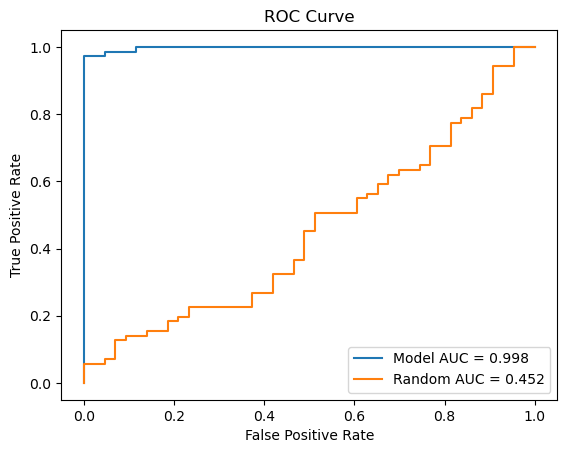

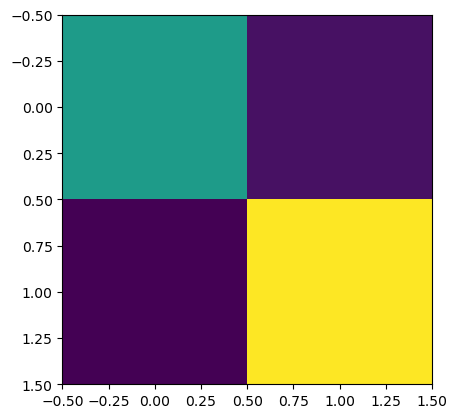

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_curve,
    auc
)

# LOAD DATASET
data = load_breast_cancer()

X = data.data
y = data.target

# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# MODEL
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

# PREDICTIONS
y_pred = model.predict(X_test)

# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)

TN, FP, FN, TP = cm.ravel()

print("Confusion Matrix")
print(cm)

print("\nTP =", TP)
print("TN =", TN)
print("FP =", FP)
print("FN =", FN)

# -----------------------------
# OWN FUNCTIONS
# -----------------------------

def accuracy(tp, tn, fp, fn):
    return (tp + tn) / (tp + tn + fp + fn)

def precision(tp, fp):
    return tp / (tp + fp)

def recall(tp, fn):
    return tp / (tp + fn)

def f1(tp, fp, fn):
    p = precision(tp, fp)
    r = recall(tp, fn)
    return 2 * p * r / (p + r)

def specificity(tn, fp):
    return tn / (tn + fp)

def npv(tn, fn):
    return tn / (tn + fn)

def mcc(tp, tn, fp, fn):
    numerator = (tp * tn) - (fp * fn)

    denominator = np.sqrt(
        (tp + fp) *
        (tp + fn) *
        (tn + fp) *
        (tn + fn)
    )

    return numerator / denominator

# OWN METRICS
print("\n--- OWN FUNCTION RESULTS ---")

print("Accuracy =", accuracy(TP, TN, FP, FN))
print("Precision =", precision(TP, FP))
print("Recall =", recall(TP, FN))
print("F1 Score =", f1(TP, FP, FN))
print("Specificity =", specificity(TN, FP))
print("NPV =", npv(TN, FN))
print("MCC =", mcc(TP, TN, FP, FN))

# -----------------------------
# SKLEARN METRICS
# -----------------------------

print("\n--- SKLEARN RESULTS ---")

print("Accuracy =", accuracy_score(y_test, y_pred))
print("Precision =", precision_score(y_test, y_pred))
print("Recall =", recall_score(y_test, y_pred))
print("F1 Score =", f1_score(y_test, y_pred))
print("MCC =", matthews_corrcoef(y_test, y_pred))

# SPECIFICITY
specificity_sklearn = TN / (TN + FP)
print("Specificity =", specificity_sklearn)

# NPV
npv_sklearn = TN / (TN + FN)
print("NPV =", npv_sklearn)

# -----------------------------
# ROC & AUC
# -----------------------------

# PREDICT PROBABILITIES
y_prob = model.predict_proba(X_test)[:, 1]

# RANDOM PROBABILITIES
random_probs = np.random.rand(len(y_test))

# ROC CURVE
fpr_model, tpr_model, _ = roc_curve(y_test, y_prob)
fpr_random, tpr_random, _ = roc_curve(y_test, random_probs)

# AUC
auc_model = auc(fpr_model, tpr_model)
auc_random = auc(fpr_random, tpr_random)

print("\nAUC OF MODEL =", auc_model)
print("AUC OF RANDOM PROBABILITIES =", auc_random)


# PLOT
plt.plot(fpr_model, tpr_model, label="Model AUC = %.3f" % auc_model)
plt.plot(fpr_random, tpr_random, label="Random AUC = %.3f" % auc_random)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()
# Plotting the Confusion Matrix (Doing it before this plt.show() causes image conflicts)
plt.imshow(cm)

## Q2 Implement and demonstrate the FIND-S algorithm for finding the most specific hypothesis based on a set of training data samples. Create your own dataset with a minimum of 4 attributes..

In [40]:
import pandas as pd

data = [
    ['Sunny', 'Warm', 'Normal', 'Strong', 'Yes'],
    ['Sunny', 'Warm', 'High', 'Strong', 'Yes'],
    ['Rainy', 'Cold', 'High', 'Strong', 'No'],
    ['Sunny', 'Warm', 'High', 'Strong', 'Yes']
]

# Define column names
columns = ['Sky', 'Temp', 'Humidity', 'Wind', 'EnjoySport']

# Create DataFrame
df = pd.DataFrame(data, columns=columns)

print(df)

hypothesis = [0] *(len(columns)-1)

for row in data :
    if row[-1] == 'Yes':
        for i in range(len(hypothesis)):

            if hypothesis[i] == '0':
                hypothesis[i] = row[i]

            elif hypothesis[i] != row[i]:
                hypothesis[i] = '?'

print("Most Specific Hypothesis")
print(hypothesis)
        


     Sky  Temp Humidity    Wind EnjoySport
0  Sunny  Warm   Normal  Strong        Yes
1  Sunny  Warm     High  Strong        Yes
2  Rainy  Cold     High  Strong         No
3  Sunny  Warm     High  Strong        Yes
Most Specific Hypothesis
['?', '?', '?', '?']


##  Q3 Implement linear and logistic regression and test it using any dataset. Give new test data predict the output. Print the confusion matrix accuracy, precision, recall, MSE , RMSE etc. Compare and write the inference.e.


----- LINEAR REGRESSION -----
Accuracy: 0.956140350877193
Precision: 0.9459459459459459
Recall: 0.9859154929577465
MSE: 0.06410886247029474
RMSE: 0.25319727974505324
Confusion Matrix:
[[39  4]
 [ 1 70]]

----- LOGISTIC REGRESSION -----
Accuracy: 0.956140350877193
Precision: 0.9459459459459459
Recall: 0.9859154929577465
MSE: 0.043859649122807015
RMSE: 0.20942695414584775
Confusion Matrix:
[[39  4]
 [ 1 70]]

NEW DATA PREDICTION
Linear Regression Prediction: [0.62168355]
Logistic Regression Prediction: [1]


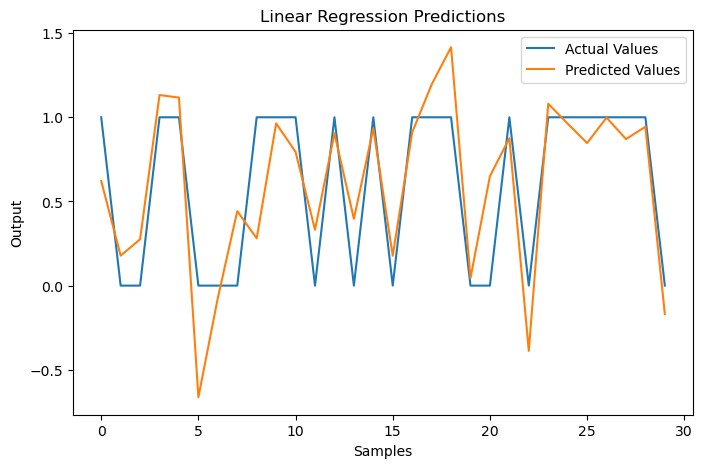

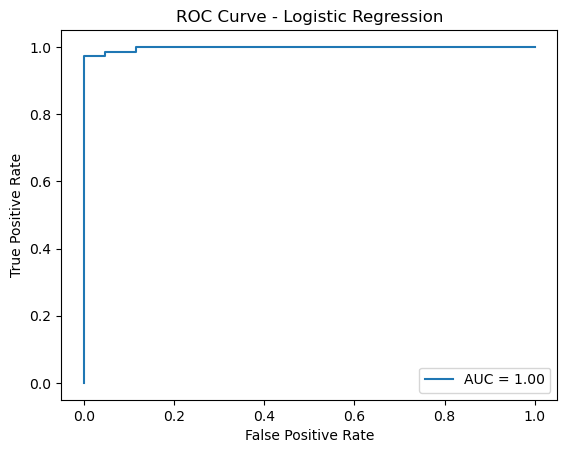

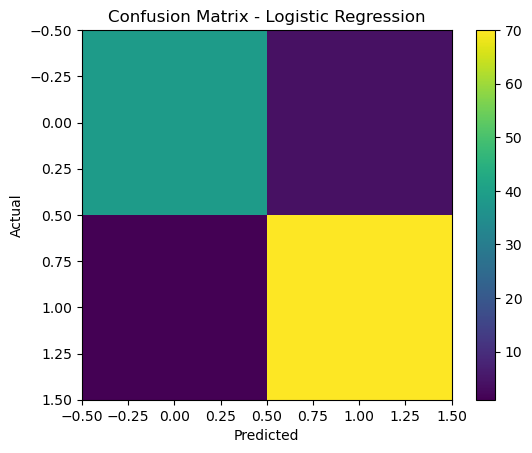

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    mean_squared_error,
    roc_curve,
    auc
)

# ---------------------------------
# DATASET
# ---------------------------------

data = load_breast_cancer()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------------
# LINEAR REGRESSION
# ---------------------------------

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

# CONVERT TO BINARY
linear_pred_binary = [1 if x > 0.5 else 0 for x in linear_pred]

# METRICS
print("\n----- LINEAR REGRESSION -----")

linear_acc = accuracy_score(y_test, linear_pred_binary)
linear_prec = precision_score(y_test, linear_pred_binary)
linear_rec = recall_score(y_test, linear_pred_binary)

print("Accuracy:", linear_acc)
print("Precision:", linear_prec)
print("Recall:", linear_rec)

mse_linear = mean_squared_error(y_test, linear_pred)
rmse_linear = np.sqrt(mse_linear)

print("MSE:", mse_linear)
print("RMSE:", rmse_linear)

cm_linear = confusion_matrix(y_test, linear_pred_binary)

print("Confusion Matrix:")
print(cm_linear)

# ---------------------------------
# LOGISTIC REGRESSION
# ---------------------------------

logistic_model = LogisticRegression(max_iter=5000)

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)

# METRICS
print("\n----- LOGISTIC REGRESSION -----")

log_acc = accuracy_score(y_test, logistic_pred)
log_prec = precision_score(y_test, logistic_pred)
log_rec = recall_score(y_test, logistic_pred)

print("Accuracy:", log_acc)
print("Precision:", log_prec)
print("Recall:", log_rec)

mse_logistic = mean_squared_error(y_test, logistic_pred)
rmse_logistic = np.sqrt(mse_logistic)

print("MSE:", mse_logistic)
print("RMSE:", rmse_logistic)

cm_logistic = confusion_matrix(y_test, logistic_pred)

print("Confusion Matrix:")
print(cm_logistic)

# ---------------------------------
# NEW TEST DATA
# ---------------------------------

new_data = [X_test[0]]

print("\nNEW DATA PREDICTION")

print("Linear Regression Prediction:",
      linear_model.predict(new_data))

print("Logistic Regression Prediction:",
      logistic_model.predict(new_data))

# =========================================================
# GRAPHS
# =========================================================

# ---------------------------------
# 4. LINEAR REGRESSION PREDICTION GRAPH
# ---------------------------------

plt.figure(figsize=(8,5))

plt.plot(y_test[:30], label='Actual Values')
plt.plot(linear_pred[:30], label='Predicted Values')

plt.title("Linear Regression Predictions")
plt.xlabel("Samples")
plt.ylabel("Output")

plt.legend()

plt.show()

# ---------------------------------
# 5. LOGISTIC REGRESSION ROC CURVE
# ---------------------------------

log_probs = logistic_model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, log_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

# ---------------------------------
# 6. CONFUSION MATRIX HEATMAP
# ---------------------------------

plt.imshow(cm_logistic)
plt.title("Confusion Matrix - Logistic Regression")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Q4  Write a program to demonstrate the working of the decision tree based ID3 algorithm. Use an 
appropriate data set for building the decision tree and apply this knowledge to classify a ne 
sample. Interpret the results. Write the inference/analysis of each output.

DATASET
  Weather    Wind Play
0   Sunny    Weak  Yes
1   Sunny  Strong   No
2   Rainy    Weak  Yes
3   Rainy  Strong   No
4   Sunny    Weak  Yes
5   Rainy    Weak  Yes

Accuracy:
1.0

Confusion Matrix:
[[2 0]
 [0 4]]

New Sample Prediction:
Play = Yes


C:\Users\kvidi\anaconda3\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


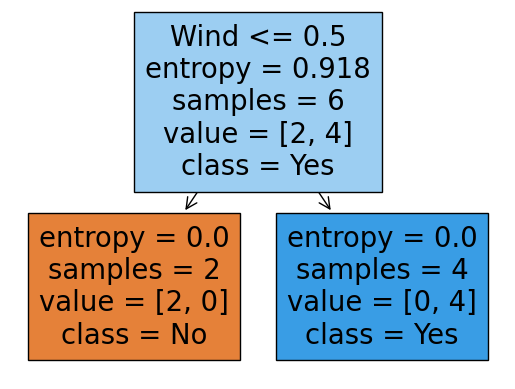

In [46]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

# ---------------------------------
# DATASET
# ---------------------------------

data = {
    'Weather': ['Sunny', 'Sunny', 'Rainy', 'Rainy', 'Sunny', 'Rainy'],
    'Wind': ['Weak', 'Strong', 'Weak', 'Strong', 'Weak', 'Weak'],
    'Play': ['Yes', 'No', 'Yes', 'No', 'Yes', 'Yes']
}

df = pd.DataFrame(data)

print("DATASET")
print(df)

# ---------------------------------
# LABEL ENCODING
# ---------------------------------

le = LabelEncoder()

df['Weather'] = le.fit_transform(df['Weather'])
df['Wind'] = le.fit_transform(df['Wind'])
df['Play'] = le.fit_transform(df['Play'])

# ---------------------------------
# INPUT AND OUTPUT
# ---------------------------------

X = df[['Weather', 'Wind']]
y = df['Play']

# ---------------------------------
# ID3 MODEL
# criterion='entropy' = ID3
# ---------------------------------

model = DecisionTreeClassifier(criterion='entropy')

model.fit(X, y)

# ---------------------------------
# PREDICTIONS
# ---------------------------------

y_pred = model.predict(X)

# ---------------------------------
# ACCURACY
# ---------------------------------

print("\nAccuracy:")
print(accuracy_score(y, y_pred))

# ---------------------------------
# CONFUSION MATRIX
# ---------------------------------

print("\nConfusion Matrix:")
print(confusion_matrix(y, y_pred))

# ---------------------------------
# NEW SAMPLE
# Sunny + Weak 
# LabelEncoder sorts alphabetically: Rainy → 0 Sunny → 1
# Similarly for : Strong → 0 Weak → 1
# ---------------------------------

new_data = [[1, 1]]

prediction = model.predict(new_data)

print("\nNew Sample Prediction:")

if prediction[0] == 1:
    print("Play = Yes")
else:
    print("Play = No")

# ---------------------------------
# DECISION TREE GRAPH
# ---------------------------------

plot_tree(
    model,
    feature_names=['Weather', 'Wind'],
    class_names=['No', 'Yes'],
    filled=True
)

plt.show()

## Q5

Accuracy:
0.9649122807017544

Confusion Matrix:
[[41  2]
 [ 2 69]]

New Sample Prediction:
No Diabetes


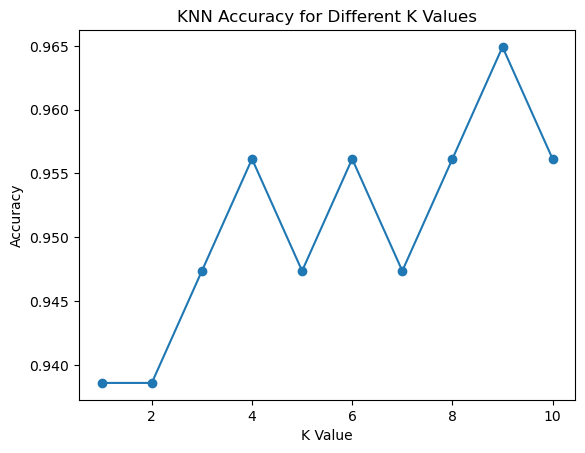

In [52]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

# LOAD DATASET
data = load_breast_cancer()
X = data.data
y = data.target

# SPLIT DATA
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# NORMALIZATION
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# KNN MODEL
# To do different distance measures, replace metric with: 'euclidean', 'manhattan'
model = KNeighborsClassifier(
    n_neighbors=5,
    metric='manhattan'
)

model.fit(X_train, y_train)
# PREDICTION
y_pred = model.predict(X_test)

# RESULTS
print("Accuracy:")
print(accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# NEW SAMPLE
new_data = [X_test[0]]
prediction = model.predict(new_data)

print("\nNew Sample Prediction:")

if prediction[0] == 1:
    print("No Diabetes")
else:
    print("Diabetes")

# DIFFERENT K VALUES
k_values = []
accuracies = []

for k in range(1, 11):

    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    acc = accuracy_score(y_test, pred)
    k_values.append(k)
    accuracies.append(acc)

# GRAPH
plt.plot(k_values, accuracies, marker='o')

plt.xlabel("K Value")
plt.ylabel("Accuracy")

plt.title("KNN Accuracy for Different K Values")

plt.show()

0.9736842105263158
k=1, metric=chebyshev, accuracy=0.9386
k=1, metric=correlation, accuracy=0.8421
k=1, metric=l2, accuracy=0.9649
k=1, metric=cosine, accuracy=0.9649
k=1, metric=hamming, accuracy=0.6667
k=1, metric=l1, accuracy=0.9649
k=1, metric=dice, accuracy=0.6579
k=1, metric=manhattan, accuracy=0.9649
k=1, metric=jaccard, accuracy=0.6579
k=2, metric=chebyshev, accuracy=0.9386


C:\Users\kvidi\anaconda3\lib\site-packages\sklearn\metrics\pairwise.py:2025: DataConversionWarning: Data was converted to boolean for metric dice
  warnings.warn(msg, DataConversionWarning)
C:\Users\kvidi\anaconda3\lib\site-packages\sklearn\metrics\pairwise.py:2025: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
C:\Users\kvidi\anaconda3\lib\site-packages\sklearn\metrics\pairwise.py:2025: DataConversionWarning: Data was converted to boolean for metric dice
  warnings.warn(msg, DataConversionWarning)


k=2, metric=correlation, accuracy=0.8333
k=2, metric=l2, accuracy=0.9561
k=2, metric=cosine, accuracy=0.9649
k=2, metric=hamming, accuracy=0.6053
k=2, metric=l1, accuracy=0.9649
k=2, metric=dice, accuracy=0.3421
k=2, metric=manhattan, accuracy=0.9649
k=2, metric=jaccard, accuracy=0.3421
k=3, metric=chebyshev, accuracy=0.9649
k=3, metric=correlation, accuracy=0.8684
k=3, metric=l2, accuracy=0.9737


C:\Users\kvidi\anaconda3\lib\site-packages\sklearn\metrics\pairwise.py:2025: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
C:\Users\kvidi\anaconda3\lib\site-packages\sklearn\metrics\pairwise.py:2025: DataConversionWarning: Data was converted to boolean for metric dice
  warnings.warn(msg, DataConversionWarning)


k=3, metric=cosine, accuracy=0.9649
k=3, metric=hamming, accuracy=0.7105
k=3, metric=l1, accuracy=0.9737
k=3, metric=dice, accuracy=0.6579
k=3, metric=manhattan, accuracy=0.9737
k=3, metric=jaccard, accuracy=0.6579
k=4, metric=chebyshev, accuracy=0.9474
k=4, metric=correlation, accuracy=0.8596
k=4, metric=l2, accuracy=0.9737


...

C:\Users\kvidi\anaconda3\lib\site-packages\sklearn\metrics\pairwise.py:2025: DataConversionWarning: Data was converted to boolean for metric dice
  warnings.warn(msg, DataConversionWarning)
C:\Users\kvidi\anaconda3\lib\site-packages\sklearn\metrics\pairwise.py:2025: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


k=18, metric=l2, accuracy=0.9737
k=18, metric=cosine, accuracy=0.9737
k=18, metric=hamming, accuracy=0.6579
k=18, metric=l1, accuracy=0.9649
k=18, metric=dice, accuracy=0.6579
k=18, metric=manhattan, accuracy=0.9649


C:\Users\kvidi\anaconda3\lib\site-packages\sklearn\metrics\pairwise.py:2025: DataConversionWarning: Data was converted to boolean for metric dice
  warnings.warn(msg, DataConversionWarning)
C:\Users\kvidi\anaconda3\lib\site-packages\sklearn\metrics\pairwise.py:2025: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


k=18, metric=jaccard, accuracy=0.6579
k=19, metric=chebyshev, accuracy=0.9561
k=19, metric=correlation, accuracy=0.8684
k=19, metric=l2, accuracy=0.9649
k=19, metric=cosine, accuracy=0.9737
k=19, metric=hamming, accuracy=0.6579
k=19, metric=l1, accuracy=0.9474
k=19, metric=dice, accuracy=0.6579
k=19, metric=manhattan, accuracy=0.9474
k=19, metric=jaccard, accuracy=0.6579


C:\Users\kvidi\anaconda3\lib\site-packages\sklearn\metrics\pairwise.py:2025: DataConversionWarning: Data was converted to boolean for metric dice
  warnings.warn(msg, DataConversionWarning)
C:\Users\kvidi\anaconda3\lib\site-packages\sklearn\metrics\pairwise.py:2025: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


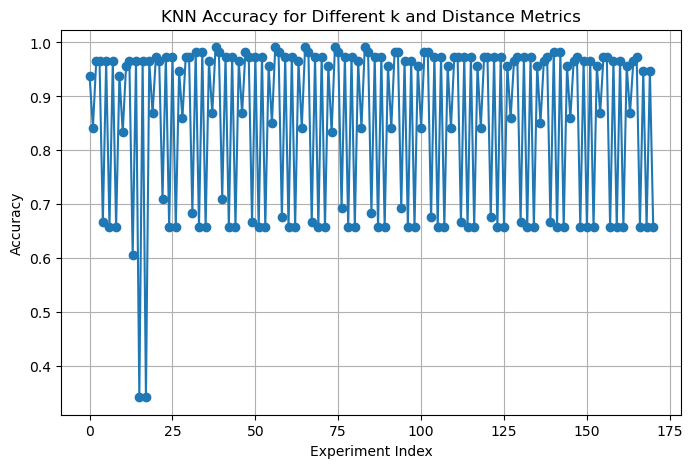

In [75]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

data = load_breast_cancer()
x = data.data
y = data.target

X_train , X_test , Y_train , Y_test = train_test_split(x,y,test_size=0.2 , random_state=23)

scalar = StandardScaler()
X_train = scalar.fit_transform(X_train)
X_test = scalar.transform(X_test)


model = KNeighborsClassifier(
        n_neighbors = 5 ,
        metric = "l1"
)
model.fit(X_train , Y_train)

Y_pred =  model.predict(X_test)
accuracy = accuracy_score(Y_test,Y_pred)
print(accuracy)

distances = ['chebyshev', 'correlation', 'l2', 'cosine', 'hamming', 'l1', 'dice','manhattan', 'jaccard']
k_means = np.arange(1,20)
accuracies = []

for i in k_means:
    for dis in distances:
        model = KNeighborsClassifier(
            n_neighbors=i,
            metric=dis
        )
        model.fit(X_train, Y_train)

        Y_pred = model.predict(X_test)
        accuracy = accuracy_score(Y_test, Y_pred)
        accuracies.append(accuracy)
        print(f"k={i}, metric={dis}, accuracy={accuracy:.4f}")

# Plot accuracies
plt.figure(figsize=(8,5))
plt.plot(accuracies, marker='o')
plt.title("KNN Accuracy for Different k and Distance Metrics")
plt.xlabel("Experiment Index")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

### Q6

In [13]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix

# ---------------------------------
# CREATE DATASET
# ---------------------------------

data = {
    'Weather': ['Sunny', 'Rainy', 'Sunny', 'Overcast', 'Rainy', 'Sunny'],
    'Temperature': ['Hot', 'Cool', 'Mild', 'Mild', 'Cool', 'Hot'],
    'Play': ['No', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
}

df = pd.DataFrame(data)

print("DATASET")
print(df)

le = LabelEncoder()
df['Weather'] = le.fit_transform(df['Weather'])
df['Temperature'] = le.fit_transform(df['Play'])
df['Play'] = le.fit_transform(df['Play'])

print(df)

X = df[['Weather','Temperature']]
Y = df['Play']

model = GaussianNB()
model.fit(X,Y)

Y_PRED = model.predict(X)

print("Accuracy" , accuracy_score(Y, Y_PRED) , "\n")
print("Confusion Matrix \n" , confusion_matrix(Y, Y_PRED))

test=[[1,1]]
pred = model.predict(test)

if pred==1:
    print("Yes")
else :
    print("No")


DATASET
    Weather Temperature Play
0     Sunny         Hot   No
1     Rainy        Cool  Yes
2     Sunny        Mild  Yes
3  Overcast        Mild  Yes
4     Rainy        Cool  Yes
5     Sunny         Hot   No
   Weather  Temperature  Play
0        2            0     0
1        1            1     1
2        2            1     1
3        0            1     1
4        1            1     1
5        2            0     0
Accuracy 1.0 

Confusion Matrix 
 [[2 0]
 [0 4]]
Yes


C:\Users\kvidi\anaconda3\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


C:\Users\kvidi\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


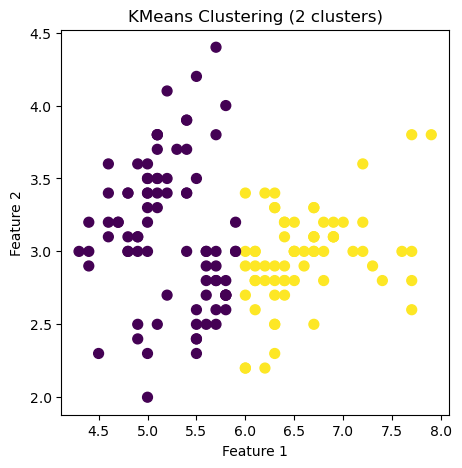

C:\Users\kvidi\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


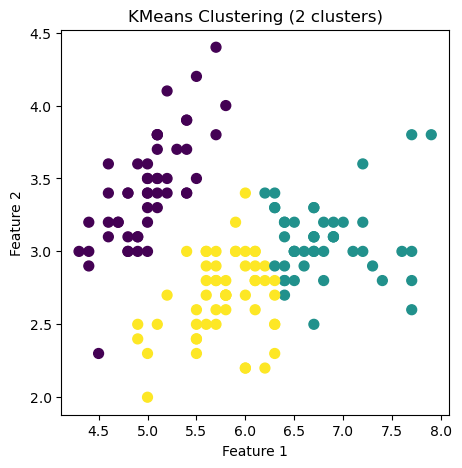

K=2 Cluster Centers
[[5.006      3.428     ]
 [6.81276596 3.07446809]
 [5.77358491 2.69245283]]


In [23]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Load data
data = load_iris()
X = data.data[:, :2]  # only first two features

model2 = KMeans(n_clusters=2, random_state=321)
clus2 = model2.fit_predict(X)


plt.figure(figsize=(5,5))
plt.scatter(X[:, 0], X[:, 1], c=clus2, cmap='viridis', s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("KMeans Clustering (2 clusters)")
plt.show()


model2 = KMeans(n_clusters=3, random_state=321)
clus2 = model2.fit_predict(X)
plt.figure(figsize=(5,5))
plt.scatter(X[:, 0], X[:, 1], c=clus2, cmap='viridis', s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("KMeans Clustering (2 clusters)")
plt.show()


print("K=2 Cluster Centers")
print(model2.cluster_centers_)

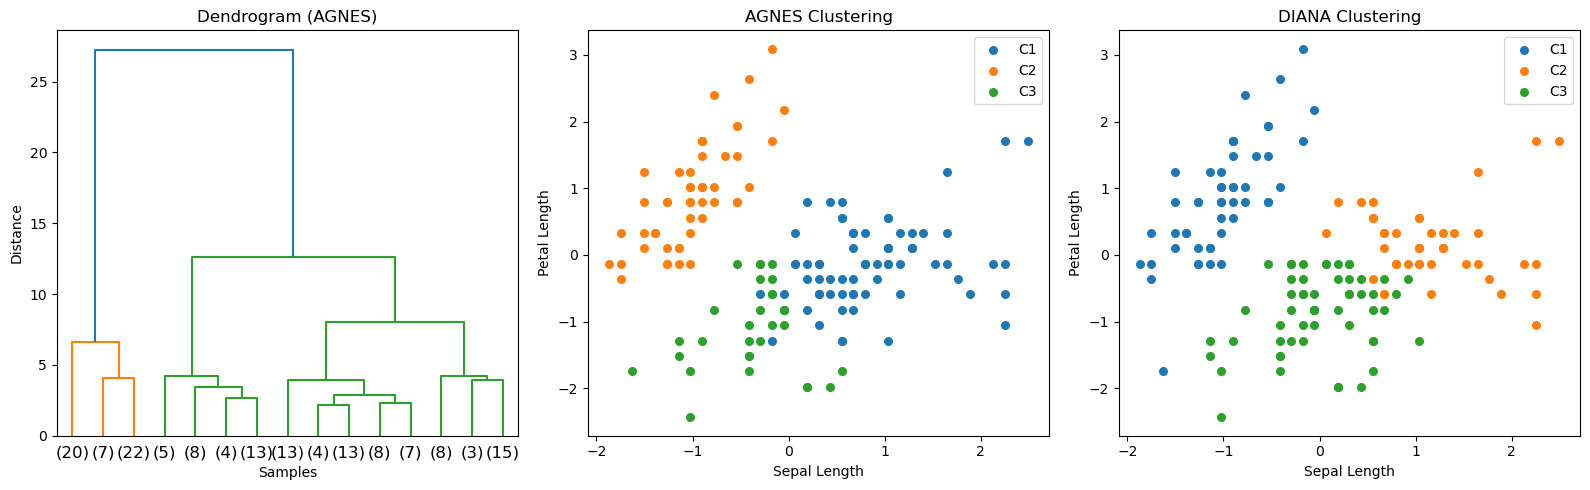

AGNES label counts: {0: 71, 1: 49, 2: 30}
DIANA label counts: {0: 50, 1: 44, 2: 56}


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform
from sklearn.datasets import load_iris

iris = load_iris()
# Convert to DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Standardize the first 4 features
X = StandardScaler().fit_transform(df.iloc[:, :4])

# ---- AGNES (Agglomerative - bottom-up) ----
agnes = AgglomerativeClustering(n_clusters=3, linkage="ward")
agnes_labels = agnes.fit_predict(X)

# ---- DIANA (Divisive - top-down, custom) ----
def diana(X, n_clusters):
    clusters = [list(range(len(X)))]
    dist_matrix = squareform(pdist(X))
    
    while len(clusters) < n_clusters:
        # Split the largest cluster
        largest = max(clusters, key=len)
        if len(largest) < 2:
            break
        clusters.remove(largest)
        
        # Find most dissimilar point (average distance to others in cluster)
        avg_dists = [np.mean([dist_matrix[i][j] for j in largest if j != i]) for i in largest]
        splinter_idx = largest[np.argmax(avg_dists)]
        
        group1, group2 = [splinter_idx], [p for p in largest if p != splinter_idx]
        # Reassign based on closer group
        changed = True
        while changed:
            changed = False
            for p in group2[:]:
                d1 = np.mean([dist_matrix[p][q] for q in group1])
                d2 = np.mean([dist_matrix[p][q] for q in group2 if q != p]) if len(group2) > 1 else np.inf
                if d1 < d2:
                    group1.append(p); group2.remove(p); changed = True
        clusters.extend([group1, group2])
    
    labels = np.zeros(len(X), dtype=int)
    for i, cluster in enumerate(clusters):
        for idx in cluster:
            labels[idx] = i
    return labels

diana_labels = diana(X, n_clusters=3)

# ---- Plots ----
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Dendrogram (for AGNES)
Z = linkage(X, method="ward")
axes[0].set_title("Dendrogram (AGNES)")
dendrogram(Z, ax=axes[0], truncate_mode="lastp", p=15)
axes[0].set_xlabel("Samples"); axes[0].set_ylabel("Distance")

# AGNES scatter
for c in range(3):
    mask = agnes_labels == c
    axes[1].scatter(X[mask, 0], X[mask, 1], label=f"C{c+1}", s=30)
axes[1].set_title("AGNES Clustering"); axes[1].legend()
axes[1].set_xlabel("Sepal Length"); axes[1].set_ylabel("Petal Length")

# DIANA scatter
for c in range(3):
    mask = diana_labels == c
    axes[2].scatter(X[mask, 0], X[mask, 1], label=f"C{c+1}", s=30)
axes[2].set_title("DIANA Clustering"); axes[2].legend()
axes[2].set_xlabel("Sepal Length"); axes[2].set_ylabel("Petal Length")

plt.tight_layout(); plt.savefig("q8_hierarchical.png", dpi=100); plt.show()
print("AGNES label counts:", {i: np.sum(agnes_labels==i) for i in range(3)})
print("DIANA label counts:", {i: np.sum(diana_labels==i) for i in range(3)})


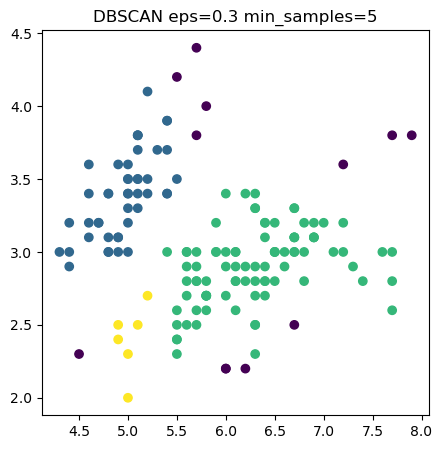

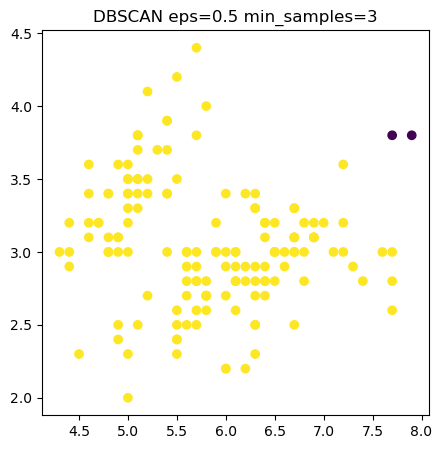

In [32]:
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.cluster import DBSCAN

# ---------------------------------
# LOAD DATASET
# ---------------------------------

data = load_iris()

X = data.data[:, :2]

# ---------------------------------
# DBSCAN 1
# ---------------------------------

model1 = DBSCAN(
    eps=0.3,
    min_samples=5
)

labels1 = model1.fit_predict(X)

plt.figure(figsize=(5,5))

plt.scatter(X[:,0], X[:,1], c=labels1)

plt.title("DBSCAN eps=0.3 min_samples=5")

plt.show()

# ---------------------------------
# DBSCAN 2
# ---------------------------------

model2 = DBSCAN(
    eps=0.5,
    min_samples=3
)

labels2 = model2.fit_predict(X)

plt.figure(figsize=(5,5))

plt.scatter(X[:,0], X[:,1], c=labels2)

plt.title("DBSCAN eps=0.5 min_samples=3")

plt.show()

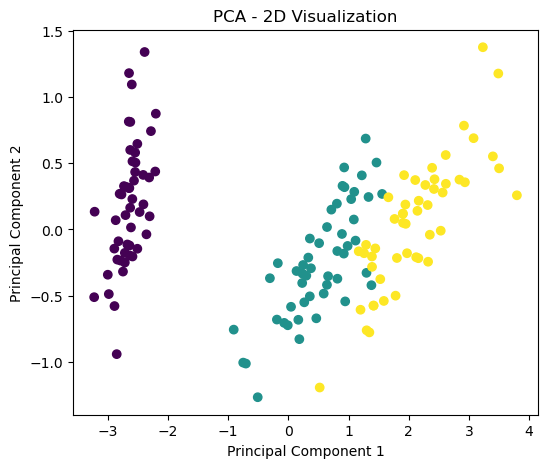

Explained Variance Ratio:
[0.92461872 0.05306648]


In [33]:
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

# ---------------------------------
# LOAD DATASET
# ---------------------------------

data = load_iris()

X = data.data
y = data.target

# ---------------------------------
# PCA
# Reduce to 2 Components
# ---------------------------------

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

# ---------------------------------
# PLOT
# ---------------------------------

plt.figure(figsize=(6,5))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA - 2D Visualization")

plt.show()

# ---------------------------------
# VARIANCE
# ---------------------------------

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)